# Notebook 03 — Multi-Method Clustering Comparison

In this notebook I demonstrate the clustering part of the assignment using multiple methods.

What I show:

1. Build clustering features from normalized text.
2. Run three clustering methods: K-Means, Agglomerative, and Spectral.
3. Compare methods across different cluster counts (max 10).
4. Evaluate with silhouette score and apply a max-cluster-size constraint.

Reader guide:

- This notebook is written as a reproducible assignment walkthrough.
- Every major step writes an output CSV to `data/results/`.
- I use one sparse TF-IDF view (for interpretation) and one dense LSA view (for methods that prefer dense space).
- At the end, I extract common cluster terms and visualize them so the clusters can be inspected qualitatively.

## Setup

Add the `src/` directory to the Python path so that project modules are importable without installing the package.

In [ ]:
import sys
from pathlib import Path

project_root_path = Path.cwd().parent
if str(project_root_path / "src") not in sys.path:
    sys.path.insert(0, str(project_root_path / "src"))

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.metrics import silhouette_score

from core.data_io import ArticleDataset
from preprocessing import TextNormalizer, TextPreprocessor

## Load data and build clustering features

Goal of this step:

- Load raw article text in original row order.
- Build two feature spaces from the same normalized text:
  - `clustering_feature_matrix`: sparse TF-IDF for interpretability.
  - `lsa_feature_matrix`: dense LSA projection for methods that work better in dense vectors.

Why this matters:

- TF-IDF keeps direct word mapping, which is needed for top-term analysis.
- LSA helps reduce sparsity and often improves distance-based behavior.

In [2]:
project_root_path = Path.cwd().parent
results_data_directory_path = project_root_path / "data" / "results"
results_data_directory_path.mkdir(parents=True, exist_ok=True)

articles_csv_path = project_root_path / "data" / "raw" / "articles.csv"
# Keep row order untouched so labels stay aligned with doc_id.
articles_data_frame = ArticleDataset(input_csv_path=articles_csv_path).load_articles()

text_normalizer = TextNormalizer()
# Build both text views in one pass (semantic view + structure-aware view).
normalized_bundle = text_normalizer.normalize_for_both_tasks(articles_data_frame["text"].tolist())

# Word-level TF-IDF for interpretable clustering.
# This matrix is used for K-Means and for top-term extraction later.
clustering_preprocessor = TextPreprocessor(
    vectorization_model_name="tfidf",
    max_features=20000,
    min_document_frequency=1,
    max_document_frequency=0.92,
    ngram_range=(1, 2),
    analyzer_mode="word",
)

clustering_feature_matrix = clustering_preprocessor.fit_transform(normalized_bundle.clustering_texts)

# Dense LSA view for methods that work better in dense space.
# Same source text, but projected into lower-dimensional dense vectors.
lsa_preprocessor = TextPreprocessor(
    vectorization_model_name="tfidf_lsa_dense",
    max_features=20000,
    min_document_frequency=1,
    max_document_frequency=0.92,
    ngram_range=(1, 2),
    analyzer_mode="word",
    dense_embedding_dimension=128,
    random_seed=42,
)
lsa_feature_matrix = lsa_preprocessor.fit_transform(normalized_bundle.clustering_texts)

clustering_feature_matrix.shape, lsa_feature_matrix.shape

((2164, 20000), (2164, 128))

## Compare methods and cluster counts

Goal of this step:

- Evaluate three clustering methods (`kmeans`, `agglomerative`, `spectral`).
- Test each method for `k` in `[2..10]` (assignment upper bound respected).
- Score each run with silhouette score.
- Keep exploring all runs until I find the best valid solution where every cluster stays under 1300 documents.

How to read this section:

- Higher silhouette score usually means better separation and cohesion.
- Spectral can fail for some settings; failures are stored instead of stopping the notebook.
- A run is valid only when `max_cluster_size < 1300`.
- All raw comparison results are exported to `notebook_03_clustering_method_metrics.csv`.

In [3]:
candidate_cluster_counts = list(range(2, 11))
max_allowed_cluster_size = 1300

# Store one row per (method, k) for reproducible comparison.
scored_rows: list[dict[str, float | int | str | bool]] = []
# Keep predicted labels so I can reuse the best run later without recomputing.
labels_by_method_and_k: dict[tuple[str, int], np.ndarray] = {}

for cluster_count in candidate_cluster_counts:
    # K-Means on sparse TF-IDF.
    kmeans_model = KMeans(n_clusters=cluster_count, n_init="auto", random_state=42)
    kmeans_labels = kmeans_model.fit_predict(clustering_feature_matrix)
    kmeans_silhouette = silhouette_score(clustering_feature_matrix, kmeans_labels)
    kmeans_cluster_sizes = pd.Series(kmeans_labels, dtype="int64").value_counts()
    kmeans_max_cluster_size = int(kmeans_cluster_sizes.max())
    scored_rows.append(
        {
            "method": "kmeans",
            "cluster_count": cluster_count,
            "silhouette_score": float(kmeans_silhouette),
            "max_cluster_size": kmeans_max_cluster_size,
            "size_constraint_ok": kmeans_max_cluster_size < max_allowed_cluster_size,
        }
    )
    labels_by_method_and_k[("kmeans", cluster_count)] = kmeans_labels

    # Agglomerative on dense LSA vectors with cosine metric.
    agglomerative_model = AgglomerativeClustering(n_clusters=cluster_count, metric="cosine", linkage="average")
    agglomerative_labels = agglomerative_model.fit_predict(lsa_feature_matrix)
    agglomerative_silhouette = silhouette_score(lsa_feature_matrix, agglomerative_labels)
    agglomerative_cluster_sizes = pd.Series(agglomerative_labels, dtype="int64").value_counts()
    agglomerative_max_cluster_size = int(agglomerative_cluster_sizes.max())
    scored_rows.append(
        {
            "method": "agglomerative",
            "cluster_count": cluster_count,
            "silhouette_score": float(agglomerative_silhouette),
            "max_cluster_size": agglomerative_max_cluster_size,
            "size_constraint_ok": agglomerative_max_cluster_size < max_allowed_cluster_size,
        }
    )
    labels_by_method_and_k[("agglomerative", cluster_count)] = agglomerative_labels

    try:
        # Spectral can be sensitive to graph settings, so keep it in try/except.
        spectral_model = SpectralClustering(
            n_clusters=cluster_count,
            affinity="nearest_neighbors",
            n_neighbors=6,
            assign_labels="kmeans",
            random_state=42,
        )
        spectral_labels = spectral_model.fit_predict(lsa_feature_matrix)
        spectral_silhouette = silhouette_score(lsa_feature_matrix, spectral_labels)
        spectral_cluster_sizes = pd.Series(spectral_labels, dtype="int64").value_counts()
        spectral_max_cluster_size = int(spectral_cluster_sizes.max())
        scored_rows.append(
            {
                "method": "spectral",
                "cluster_count": cluster_count,
                "silhouette_score": float(spectral_silhouette),
                "max_cluster_size": spectral_max_cluster_size,
                "size_constraint_ok": spectral_max_cluster_size < max_allowed_cluster_size,
            }
        )
        labels_by_method_and_k[("spectral", cluster_count)] = spectral_labels
    except Exception as spectral_error:
        # Log failure details but continue notebook execution.
        scored_rows.append(
            {
                "method": "spectral",
                "cluster_count": cluster_count,
                "silhouette_score": np.nan,
                "max_cluster_size": np.nan,
                "size_constraint_ok": False,
                "error": str(spectral_error),
            }
        )

# Sort rows for easier manual reading.
clustering_metrics_data_frame = pd.DataFrame(scored_rows).sort_values(
    ["method", "silhouette_score"], ascending=[True, False]
)
clustering_metrics_data_frame.to_csv(
    results_data_directory_path / "notebook_03_clustering_method_metrics.csv", index=False
)
clustering_metrics_data_frame.head(20)

,method,cluster_count,silhouette_score,max_cluster_size,size_constraint_ok
1,agglomerative,2,0.340938,2114,False
4,agglomerative,3,0.303486,2111,False
7,agglomerative,4,0.302216,2108,False
13,agglomerative,6,0.224032,2027,False
10,agglomerative,5,0.221240,2034,False
16,agglomerative,7,0.068547,1629,False
19,agglomerative,8,0.053165,1124,True
25,agglomerative,10,0.026050,1082,True
22,agglomerative,9,0.023135,1106,True
18,kmeans,8,0.012653,866,True


## Why the max-cluster-size rule is needed (demonstration)

Before applying the size rule, I first inspect the best silhouette run **per method**
without any cluster-size constraint. This shows whether a method naturally picks
very imbalanced partitions.

In [4]:
unconstrained_best_rows = (
    clustering_metrics_data_frame.dropna(subset=["silhouette_score"])
    .sort_values(["method", "silhouette_score"], ascending=[True, False])
    .groupby("method", as_index=False)
    .first()
)

unconstrained_best_rows[["method", "cluster_count", "silhouette_score", "max_cluster_size"]]

,method,cluster_count,silhouette_score,max_cluster_size
0,agglomerative,2,0.340938,2114
1,kmeans,8,0.012653,866
2,spectral,9,0.092252,2015


### Unconstrained best-run max cluster size graph

If a method's unconstrained best row has a very high `max_cluster_size`
(for example 1.8k+), that means the method is rewarding an imbalanced solution.

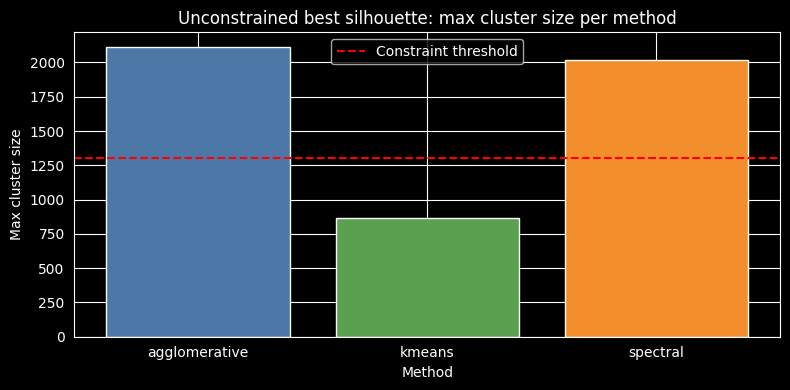

In [5]:
plt.figure(figsize=(8, 4))
plt.bar(
    unconstrained_best_rows["method"],
    unconstrained_best_rows["max_cluster_size"],
    color=["#4C78A8", "#59A14F", "#F28E2B"],
)
plt.axhline(max_allowed_cluster_size, color="red", linestyle="--", linewidth=1.5, label="Constraint threshold")
plt.title("Unconstrained best silhouette: max cluster size per method")
plt.xlabel("Method")
plt.ylabel("Max cluster size")
plt.legend()
plt.tight_layout()
plt.show()

### Runs that violate the size rule

This table lists high-silhouette runs where one cluster is too large.
These are exactly the runs that the constraint removes.

In [6]:
violating_rows = clustering_metrics_data_frame.loc[
    clustering_metrics_data_frame["size_constraint_ok"] == False, :  # noqa: E712
].dropna(subset=["silhouette_score"])

violating_rows.sort_values(["method", "silhouette_score"], ascending=[True, False]).head(20)

,method,cluster_count,silhouette_score,max_cluster_size,size_constraint_ok
1,agglomerative,2,0.340938,2114,False
4,agglomerative,3,0.303486,2111,False
7,agglomerative,4,0.302216,2108,False
13,agglomerative,6,0.224032,2027,False
10,agglomerative,5,0.221240,2034,False
16,agglomerative,7,0.068547,1629,False
3,kmeans,3,0.007802,1428,False
0,kmeans,2,0.007686,2094,False
23,spectral,9,0.092252,2015,False
20,spectral,8,0.081308,2032,False


### Why this happens more with Spectral and Agglomerative than K-Means here

In this notebook, Spectral and Agglomerative are trained on dense LSA vectors,
while K-Means is trained on sparse TF-IDF vectors. The algorithms also optimize
very different objectives.

For Agglomerative (`average` linkage with cosine), merges are based on pairwise
similarity between groups. In text data, this can create a large "background"
cluster that absorbs many borderline points, while smaller tight clusters remain
separate. The silhouette can still look good, because many points in the large
cluster are relatively close to each other compared with their nearest other
cluster.

For Spectral (nearest-neighbor affinity), clustering depends on graph structure.
When the graph has one big connected component plus a few denser pockets,
partitioning can produce one very large block and several smaller ones. Again,
this can score well in silhouette even if cluster sizes are not useful for
interpretation.

K-Means, on the other hand, assigns points to centroids and minimizes within-
cluster variance. With a fixed `k`, centroid competition often spreads points
more across clusters than graph/hierarchical methods in this setup. It can still
be imbalanced, but in this notebook it is less likely to produce the same extreme
single-cluster dominance.

## Save best label set per method

Goal of this step:

- Pick the best `k` for each method using silhouette score.
- Keep only valid runs where all clusters are smaller than 1300 documents.
- Export labels in original document order so outputs can be joined back to `doc_id`.

Exports:

- `notebook_03_best_method_labels.csv`: one column per best method label set.
- `notebook_03_best_method_summary.csv`: selected best score and `k` per method.
- `notebook_03_best_constrained_solution.csv`: single best valid setup across all methods.
- `notebook_03_best_constrained_labels.csv`: labels for that single best valid setup.

In [7]:
valid_rows = clustering_metrics_data_frame.loc[
    clustering_metrics_data_frame["size_constraint_ok"] == True, :  # noqa: E712
].dropna(subset=["silhouette_score"])

if valid_rows.empty:
    raise ValueError("No valid clustering run found where all clusters are smaller than 1300 documents.")

# Best valid row per method.
best_rows = (
    valid_rows.sort_values(["method", "silhouette_score"], ascending=[True, False])
    .groupby("method", as_index=False)
    .first()
)

# Also keep one global winner across all methods under the same size constraint.
best_constrained_solution_row = valid_rows.sort_values("silhouette_score", ascending=False).head(1).copy()
selected_best_method_name = str(best_constrained_solution_row.iloc[0]["method"])
selected_best_cluster_count = int(best_constrained_solution_row.iloc[0]["cluster_count"])
selected_best_labels = labels_by_method_and_k[(selected_best_method_name, selected_best_cluster_count)]

best_constrained_solution_row.to_csv(
    results_data_directory_path / "notebook_03_best_constrained_solution.csv", index=False
)

best_constrained_labels_table = pd.DataFrame(
    {
        "doc_id": articles_data_frame["doc_id"].tolist(),
        "label": selected_best_labels,
    }
)
best_constrained_labels_table.to_csv(
    results_data_directory_path / "notebook_03_best_constrained_labels.csv", index=False
)

# Start with IDs to keep output directly traceable.
best_label_table = pd.DataFrame({"doc_id": articles_data_frame["doc_id"].tolist()})

for _, row in best_rows.iterrows():
    method_name = str(row["method"])
    selected_cluster_count = int(row["cluster_count"])
    # Reuse stored labels from earlier loop.
    selected_labels = labels_by_method_and_k[(method_name, selected_cluster_count)]
    best_label_table[f"{method_name}_k{selected_cluster_count}"] = selected_labels

best_label_table.to_csv(results_data_directory_path / "notebook_03_best_method_labels.csv", index=False)
best_rows.to_csv(results_data_directory_path / "notebook_03_best_method_summary.csv", index=False)

print("Best constrained overall solution:")
print(
    best_constrained_solution_row[["method", "cluster_count", "silhouette_score", "max_cluster_size"]].to_string(
        index=False
    )
)

best_rows

,method,cluster_count,silhouette_score,max_cluster_size,size_constraint_ok
0,agglomerative,8,0.053165,1124,True
1,kmeans,8,0.012653,866,True


## Cluster size diagnostics for each best method

Goal of this step:

- Check whether any best-method solution creates very tiny or very dominant clusters.

Why this matters:

- Silhouette alone can hide imbalanced partitions.
- Size diagnostics help detect unstable or overly broad clusters.

Export:

- `notebook_03_cluster_size_table.csv`

In [8]:
cluster_size_rows: list[dict[str, int | str]] = []

for _, row in best_rows.iterrows():
    method_name = str(row["method"])
    selected_cluster_count = int(row["cluster_count"])
    selected_labels = labels_by_method_and_k[(method_name, selected_cluster_count)]
    # Count docs per cluster label.
    label_counts = pd.Series(selected_labels, dtype="int64").value_counts().sort_index()
    for label_value, label_count in label_counts.items():
        cluster_size_rows.append(
            {
                "method": method_name,
                "cluster_count": selected_cluster_count,
                "label": label_value,
                "document_count": int(label_count),
            }
        )

cluster_size_table = pd.DataFrame(cluster_size_rows)
cluster_size_table.to_csv(results_data_directory_path / "notebook_03_cluster_size_table.csv", index=False)
cluster_size_table.head(20)

,method,cluster_count,label,document_count
0,agglomerative,8,0,1124
1,agglomerative,8,1,505
2,agglomerative,8,2,398
3,agglomerative,8,3,74
4,agglomerative,8,4,50
5,agglomerative,8,5,3
6,agglomerative,8,6,7
7,agglomerative,8,7,3
8,kmeans,8,0,70
9,kmeans,8,1,866


### Cluster-size distribution graphs per method

I plot the number of documents per cluster for each method in separate cells.
This makes it easier to compare balance without mixing all methods in one figure.

#### K-Means cluster-size distribution

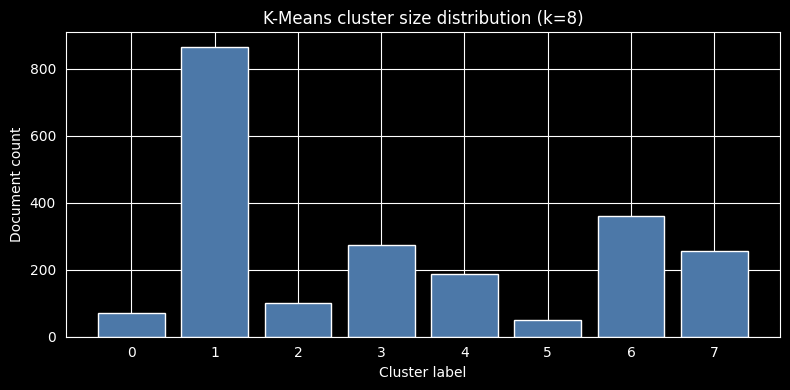

In [9]:
kmeans_cluster_size_rows = cluster_size_table.loc[cluster_size_table["method"] == "kmeans", :].sort_values("label")

if kmeans_cluster_size_rows.empty:
    print("No K-Means cluster-size rows available.")
else:
    plt.figure(figsize=(8, 4))
    plt.bar(
        kmeans_cluster_size_rows["label"].astype(str),
        kmeans_cluster_size_rows["document_count"],
        color="#4C78A8",
    )
    selected_kmeans_k = int(kmeans_cluster_size_rows["cluster_count"].iloc[0])
    plt.title(f"K-Means cluster size distribution (k={selected_kmeans_k})")
    plt.xlabel("Cluster label")
    plt.ylabel("Document count")
    plt.tight_layout()
    plt.show()

#### Agglomerative cluster-size distribution

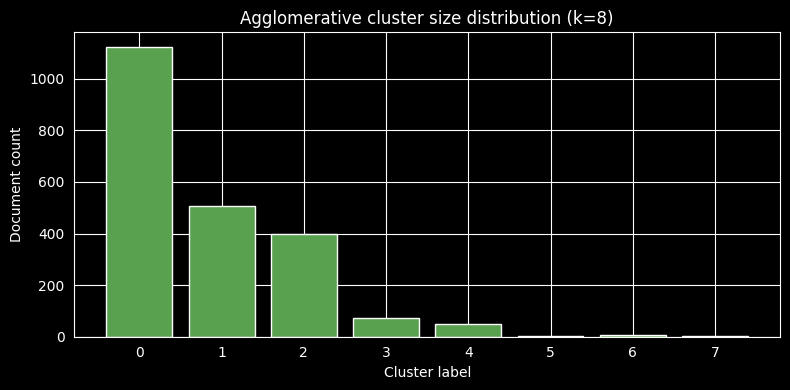

In [10]:
agglomerative_cluster_size_rows = cluster_size_table.loc[
    cluster_size_table["method"] == "agglomerative", :
].sort_values("label")

if agglomerative_cluster_size_rows.empty:
    print("No Agglomerative cluster-size rows available.")
else:
    plt.figure(figsize=(8, 4))
    plt.bar(
        agglomerative_cluster_size_rows["label"].astype(str),
        agglomerative_cluster_size_rows["document_count"],
        color="#59A14F",
    )
    selected_agglomerative_k = int(agglomerative_cluster_size_rows["cluster_count"].iloc[0])
    plt.title(f"Agglomerative cluster size distribution (k={selected_agglomerative_k})")
    plt.xlabel("Cluster label")
    plt.ylabel("Document count")
    plt.tight_layout()
    plt.show()

#### Spectral cluster-size distribution

In [11]:
spectral_cluster_size_rows = cluster_size_table.loc[cluster_size_table["method"] == "spectral", :].sort_values("label")

if spectral_cluster_size_rows.empty:
    print("No Spectral cluster-size rows available.")
else:
    plt.figure(figsize=(8, 4))
    plt.bar(
        spectral_cluster_size_rows["label"].astype(str),
        spectral_cluster_size_rows["document_count"],
        color="#F28E2B",
    )
    selected_spectral_k = int(spectral_cluster_size_rows["cluster_count"].iloc[0])
    plt.title(f"Spectral cluster size distribution (k={selected_spectral_k})")
    plt.xlabel("Cluster label")
    plt.ylabel("Document count")
    plt.tight_layout()
    plt.show()

No Spectral cluster-size rows available.


## Common terms per cluster and visualization

Goal of this step:

- Make cluster meaning visible by extracting top terms per cluster.
- Plot readable per-cluster bar charts for each best method.

How common terms are computed:

- For each cluster, compute the **mean TF-IDF** vector of all cluster documents.
- Rank terms by descending mean TF-IDF.
- Keep top 12 terms (top 10 shown in the graph).

Export:

- `notebook_03_cluster_top_terms.csv`

In [12]:
# Get TF-IDF feature names once for term lookup.
feature_name_list = clustering_preprocessor.get_feature_names()

cluster_top_term_rows: list[dict[str, int | float | str]] = []

for _, row in best_rows.iterrows():
    method_name = str(row["method"])
    selected_cluster_count = int(row["cluster_count"])
    selected_labels = labels_by_method_and_k[(method_name, selected_cluster_count)]

    unique_label_values = pd.Series(selected_labels, dtype="int64").unique().tolist()
    for label_value in sorted(unique_label_values):
        # Select docs belonging to current cluster.
        matching_document_mask = selected_labels == label_value

        # Use mean TF-IDF to find words that define this cluster.
        cluster_mean_vector = np.asarray(clustering_feature_matrix[matching_document_mask].mean(axis=0)).ravel()
        top_term_indices = np.argsort(cluster_mean_vector)[::-1][:12]

        for rank_value, term_index in enumerate(top_term_indices, start=1):
            cluster_top_term_rows.append(
                {
                    "method": method_name,
                    "cluster_count": selected_cluster_count,
                    "label": int(label_value),
                    "rank": int(rank_value),
                    "term": str(feature_name_list[term_index]),
                    "mean_tfidf": float(cluster_mean_vector[term_index]),
                }
            )

cluster_top_terms_table = pd.DataFrame(cluster_top_term_rows)
cluster_top_terms_table.to_csv(results_data_directory_path / "notebook_03_cluster_top_terms.csv", index=False)

# Print top terms for quick reading in plain text.
for _, row in best_rows.iterrows():
    method_name = str(row["method"])
    selected_cluster_count = int(row["cluster_count"])
    print(f"\nTop terms for {method_name} (k={selected_cluster_count})")

    method_rows = cluster_top_terms_table[
        (cluster_top_terms_table["method"] == method_name)
        & (cluster_top_terms_table["cluster_count"] == selected_cluster_count)
    ].sort_values(["label", "rank"])

    print(method_rows[["label", "rank", "term", "mean_tfidf"]].head(48).to_string(index=False))


# Plot per method with one bar chart per cluster.
# Plot helper for one method only.
def plot_top_terms_for_method(method_name: str) -> None:
    """Plot per-cluster top terms for one selected method.

    Args:
        method_name: One of 'kmeans', 'agglomerative', or 'spectral'.
    """
    method_best_rows = best_rows.loc[best_rows["method"] == method_name, :]
    if method_best_rows.empty:
        print(f"No valid best row found for method '{method_name}'.")
        return

    selected_cluster_count = int(method_best_rows.iloc[0]["cluster_count"])

    method_rows = cluster_top_terms_table[
        (cluster_top_terms_table["method"] == method_name)
        & (cluster_top_terms_table["cluster_count"] == selected_cluster_count)
    ]

    if method_rows.empty:
        print(f"No top-term rows found for method '{method_name}' and k={selected_cluster_count}.")
        return

    unique_labels = sorted(method_rows["label"].unique().tolist())

    # One subplot per cluster to keep term comparison clean.
    figure, axis_array = plt.subplots(
        nrows=len(unique_labels),
        ncols=1,
        figsize=(10, max(3.5, 2.8 * len(unique_labels))),
        constrained_layout=True,
    )
    if len(unique_labels) == 1:
        axis_array = [axis_array]

    for axis, label_value in zip(axis_array, unique_labels):
        cluster_rows = method_rows.loc[method_rows["label"] == label_value, :].sort_values(
            by="mean_tfidf", ascending=True
        )

        # Keep bars short so plot stays readable.
        cluster_rows = cluster_rows.tail(10)

        axis.barh(cluster_rows["term"], cluster_rows["mean_tfidf"], color="#4C78A8")
        axis.set_title(f"Cluster {label_value} top terms")
        axis.set_xlabel("Mean TF-IDF")
        axis.set_ylabel("Term")

    figure.suptitle(f"{method_name} common terms (k={selected_cluster_count})", fontsize=13)
    plt.show()


Top terms for agglomerative (k=8)
 label  rank                term  mean_tfidf
     0     1                 car    0.022271
     0     2                like    0.017281
     0     3                just    0.017055
     0     4               think    0.014422
     0     5               space    0.014138
     0     6                year    0.014088
     0     7                know    0.013824
     0     8              people    0.013717
     0     9                time    0.013508
     0    10               thing    0.012620
     0    11                 doe    0.012359
     0    12             problem    0.011658
     1     1               thank    0.028222
     1     2                file    0.026680
     1     3             graphic    0.023697
     1     4             program    0.022659
     1     5               image    0.021238
     1     6                know    0.020772
     1     7                help    0.017879
     1     8                 doe    0.017256
     1     9        

### K-Means top cluster-term graphs

This cell only plots the best K-Means run.

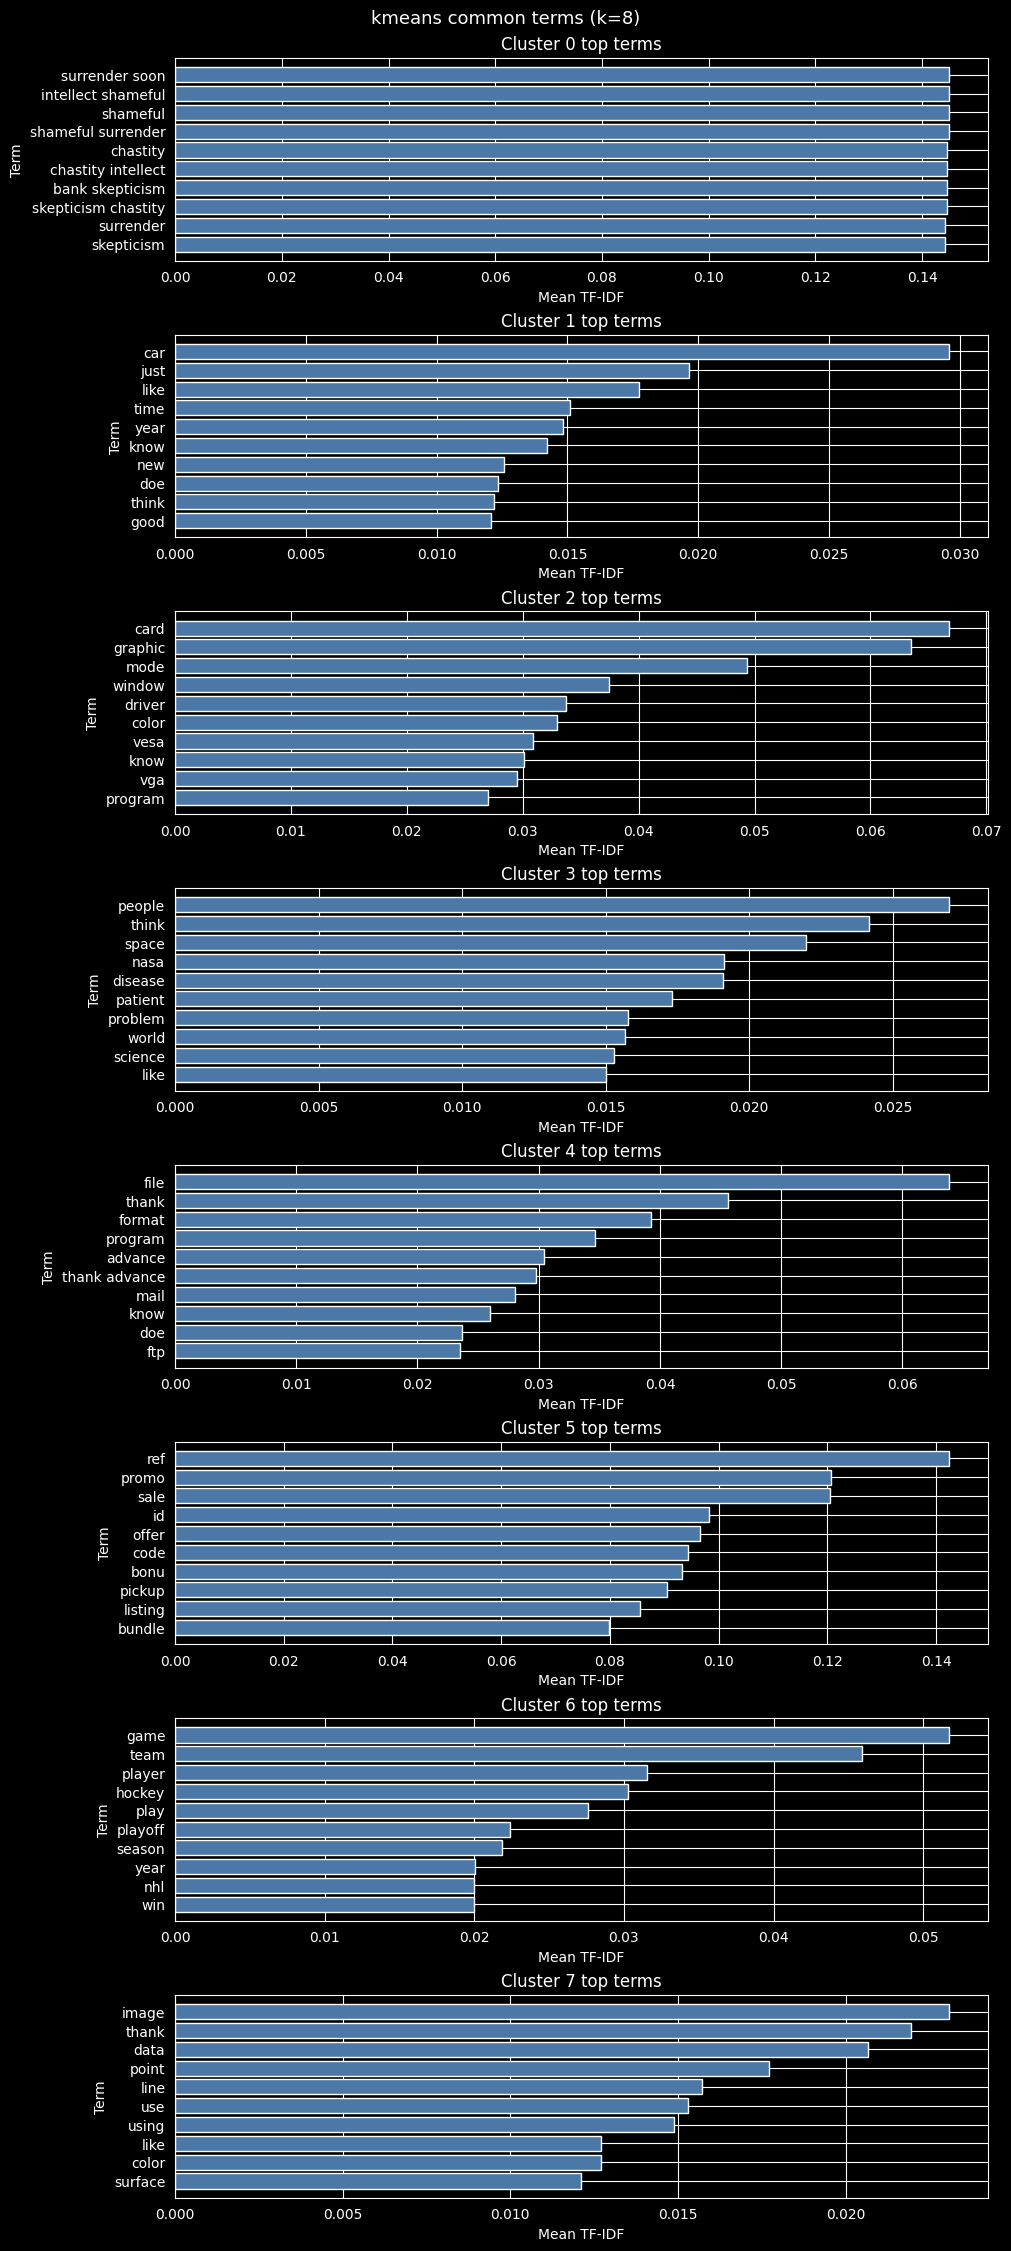

In [13]:
plot_top_terms_for_method("kmeans")

### Agglomerative top cluster-term graphs

This cell only plots the best Agglomerative run.

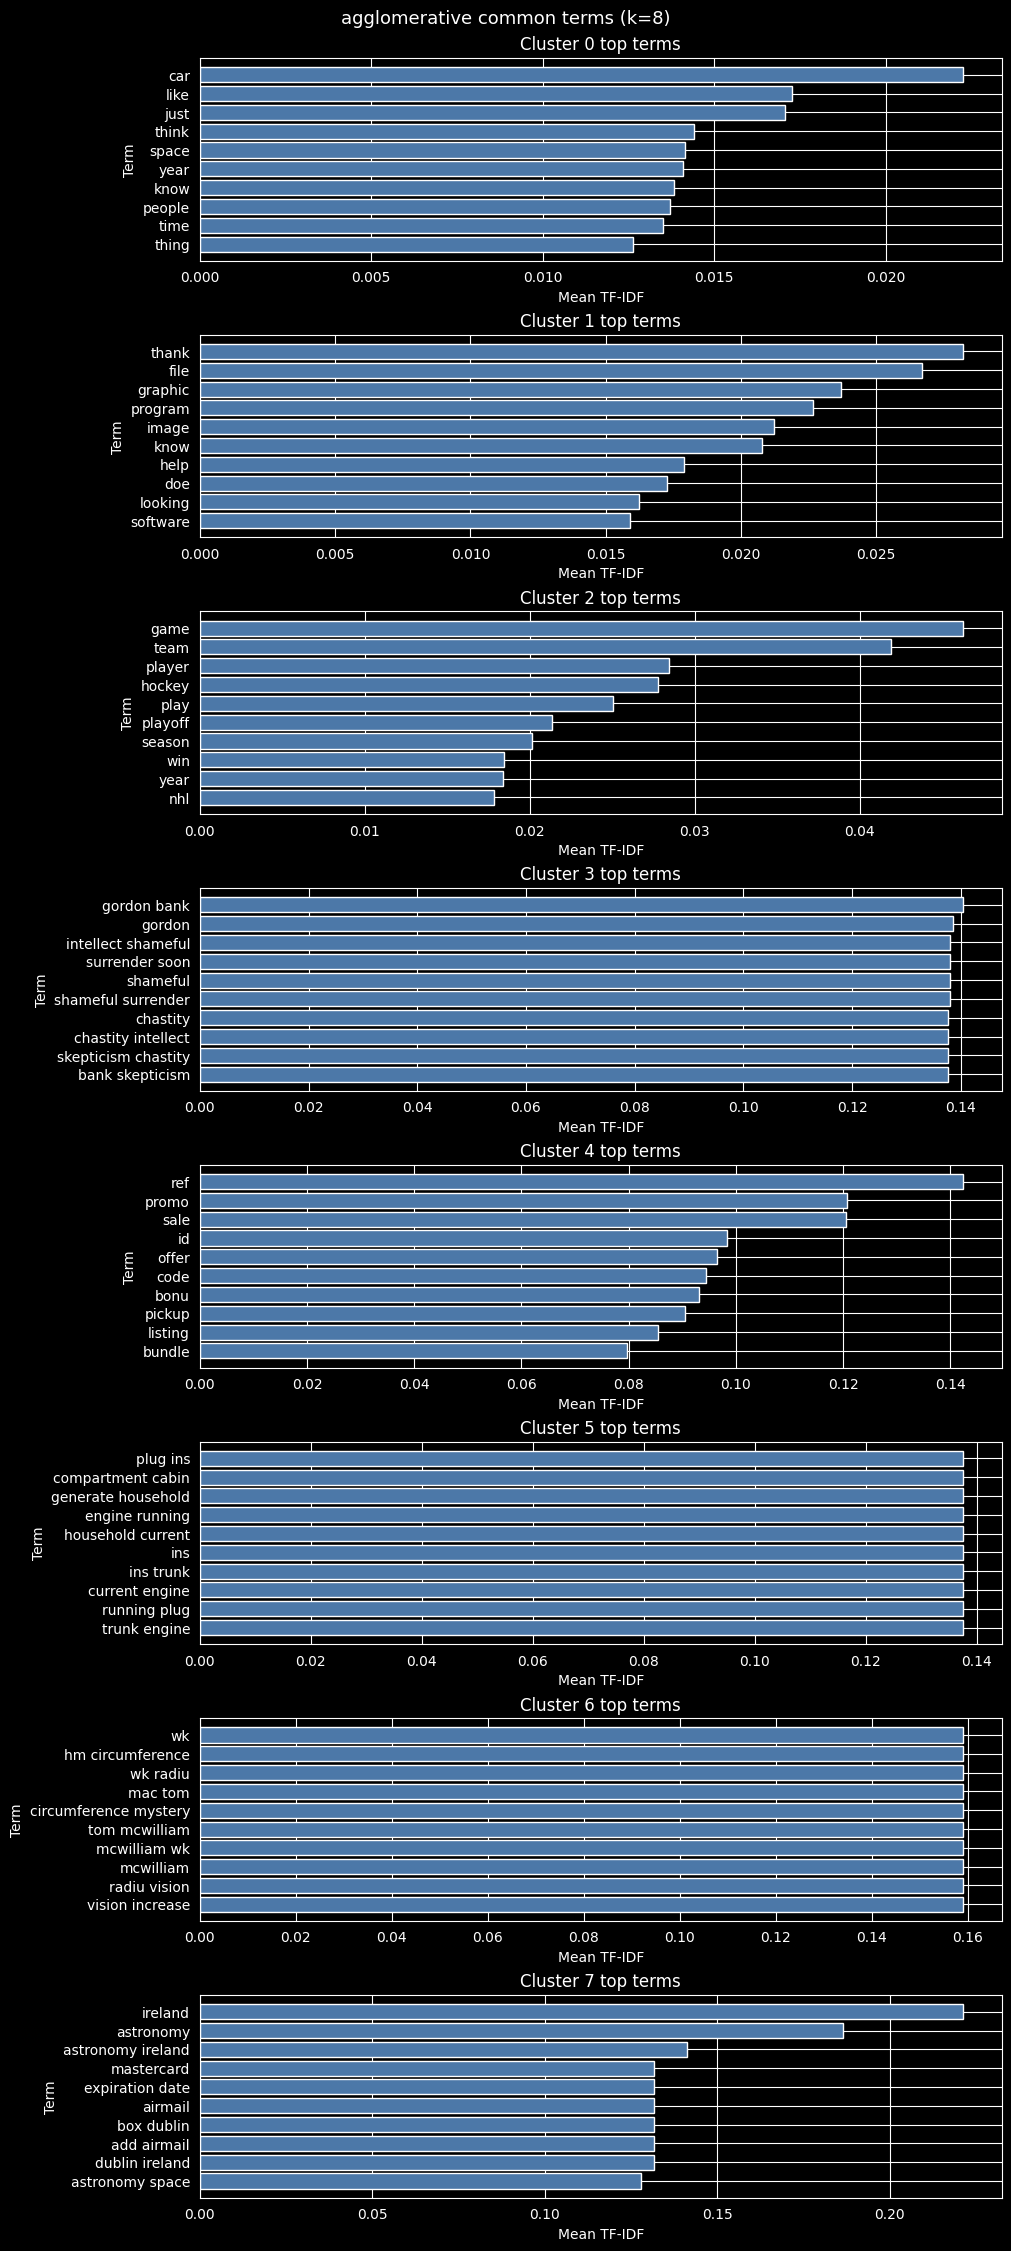

In [14]:
plot_top_terms_for_method("agglomerative")

### Spectral top cluster-term graphs

This cell only plots the best Spectral run.

In [15]:
plot_top_terms_for_method("spectral")

No valid best row found for method 'spectral'.


### Why K-Means can score lower silhouette here

In this notebook, K-Means is trained on sparse TF-IDF vectors, while Agglomerative and Spectral are trained on dense LSA vectors. This difference is important.

K-Means works best when clusters are close to spherical and separable in Euclidean space. Sparse TF-IDF text data often breaks these assumptions: distances become less informative in very high dimensions, and topic shapes can be irregular. Because of that, K-Means can create less compact clusters and lower silhouette values.

Agglomerative and Spectral can do better here for two reasons. First, I run them on LSA-reduced dense vectors, which usually improves distance quality. Second, their clustering logic is more flexible for non-spherical structures (hierarchical merging and graph-based partitioning), so they can separate text groups that K-Means struggles with.

So the lower K-Means score in this notebook does not mean K-Means is always bad. It mostly reflects the combination of feature space (sparse TF-IDF) and cluster geometry assumptions.



## Files produced by this notebook

| File | Description |
|---|---|
| `data/results/notebook_03_clustering_method_metrics.csv` | Silhouette score and max cluster size for every (method, k) combination |
| `data/results/notebook_03_best_constrained_solution.csv` | Single globally best valid (method, k) under the 1300-document constraint |
| `data/results/notebook_03_best_constrained_labels.csv` | Document labels for the best constrained solution |
| `data/results/notebook_03_best_method_labels.csv` | Best per-method labels (one column per method) |
| `data/results/notebook_03_best_method_summary.csv` | Selected best score and `k` per method |
| `data/results/notebook_03_cluster_size_table.csv` | Document count per cluster for each best method |
| `data/results/notebook_03_cluster_top_terms.csv` | Top 12 mean-TF-IDF terms per cluster for each best method |